# Medical Insurance Cost Prediction and Risk Factor Analysis

## Project Overview

This project analyses a medical insurance dataset to identify the main factors associated with healthcare charges and to build predictive models capable of estimating medical costs.

The analysis focuses on three core questions:

1. Which variables have the greatest influence on medical insurance charges?
2. What is the impact of smoking on medical costs?
3. What proportion of smokers are women, and how do medical costs differ across gender and smoking groups?

The workflow includes data cleaning, exploratory data analysis, feature encoding, model training, model comparison, and final business recommendations.


In [52]:
import pandas as pd 
df=pd.read_csv("Medical_insurance.csv")

## Data Cleaning and Preprocessing

In [53]:
df.head=df.columns

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 151.7 KB


In [55]:
df[["sex","smoker","region"]]

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
2767,female,no,southeast
2768,female,no,southwest
2769,male,yes,northwest
2770,male,no,northwest


In [56]:
#replace the categorigal vlaues to numerical ones
#df["sex"] = df["sex"].replace({"female": 1, "male": 2})
#df["smoker"]=df["smoker"].replace({"yes":1 ,"no":2})
df = pd.get_dummies(df, columns=["sex","smoker","region"], dtype=int)

In [57]:
#check if dataset contain null values 
df.isnull().sum()

age                 0
bmi                 0
children            0
charges             0
sex_female          0
sex_male            0
smoker_no           0
smoker_yes          0
region_northeast    0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

In [58]:
df.isna().sum()

age                 0
bmi                 0
children            0
charges             0
sex_female          0
sex_male            0
smoker_no           0
smoker_yes          0
region_northeast    0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

In [60]:
df.corr(numeric_only=True)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,0.113048,0.037574,0.298624,0.026046,-0.026046,0.023286,-0.023286,0.005290,-0.001130,-0.015242,0.011708
bmi,0.113048,1.000000,-0.001492,0.199846,-0.042924,0.042924,-0.011489,0.011489,-0.140522,-0.142325,0.280058,-0.010913
children,0.037574,-0.001492,1.000000,0.066442,-0.016020,0.016020,-0.006362,0.006362,-0.022994,0.029541,-0.030504,0.025088
charges,0.298624,0.199846,0.066442,1.000000,-0.062837,0.062837,-0.788783,0.788783,0.009850,-0.036874,0.075652,-0.051686
sex_female,0.026046,-0.042924,-0.016020,-0.062837,1.000000,-1.000000,0.082326,-0.082326,-0.000428,0.018243,-0.021740,0.004912
sex_male,-0.026046,0.042924,0.016020,0.062837,-1.000000,1.000000,-0.082326,0.082326,0.000428,-0.018243,0.021740,-0.004912
smoker_no,0.023286,-0.011489,-0.006362,-0.788783,0.082326,-0.082326,1.000000,-1.000000,-0.004468,0.035902,-0.072435,0.044001
smoker_yes,-0.023286,0.011489,0.006362,0.788783,-0.082326,0.082326,-1.000000,1.000000,0.004468,-0.035902,0.072435,-0.044001
region_northeast,0.005290,-0.140522,-0.022994,0.009850,-0.000428,0.000428,-0.004468,0.004468,1.000000,-0.313119,-0.344754,-0.319318
region_northwest,-0.001130,-0.142325,0.029541,-0.036874,0.018243,-0.018243,0.035902,-0.035902,-0.313119,1.000000,-0.346815,-0.321227


In [61]:
df.dtypes

age                   int64
bmi                 float64
children              int64
charges             float64
sex_female            int64
sex_male              int64
smoker_no             int64
smoker_yes            int64
region_northeast      int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

In [64]:
df.shape

(2772, 12)

In [65]:
df.duplicated().sum()

np.int64(1435)

In [66]:
#We delete duplciates vlaues here 
df = df.drop_duplicates()

In [67]:
df.shape

(1337, 12)

In [68]:
#After verfy that we dont have duplciated values 
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

In [69]:
df.describe(include="all")

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487,0.495138,0.504862,0.795064,0.204936,0.242334,0.242334,0.272251,0.243082
std,14.044333,6.100468,1.205571,12110.359656,0.500163,0.500163,0.403806,0.403806,0.428655,0.428655,0.445285,0.429104
min,18.000000,15.960000,0.000000,1121.873900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,26.290000,0.000000,4746.344000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,30.400000,1.000000,9386.161300,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,51.000000,34.700000,2.000000,16657.717450,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,64.000000,53.130000,5.000000,63770.428010,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Univariate Analysis

<Axes: xlabel='age', ylabel='Count'>

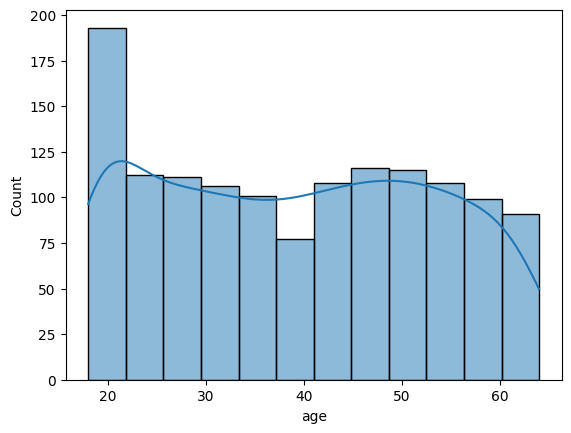

In [ ]:
sns.histplot(df["age"], kde=True)

<Axes: xlabel='age'>

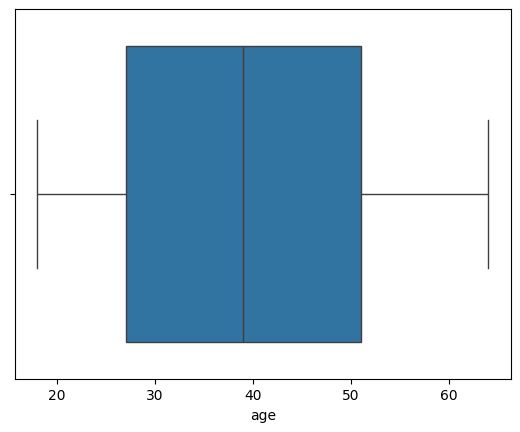

In [74]:
sns.boxplot(x=df["age"])

<Axes: xlabel='bmi', ylabel='Count'>

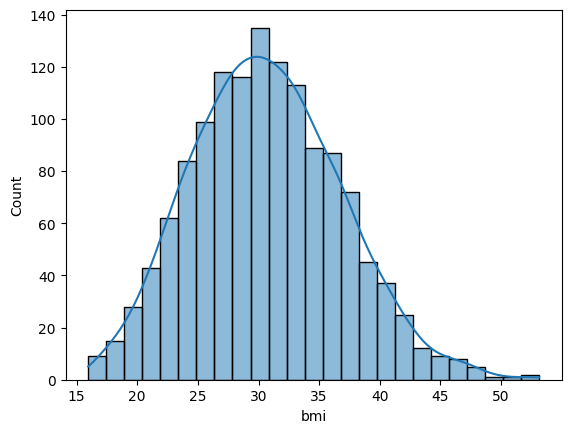

In [75]:
sns.histplot(df["bmi"], kde=True)

<Axes: xlabel='bmi'>

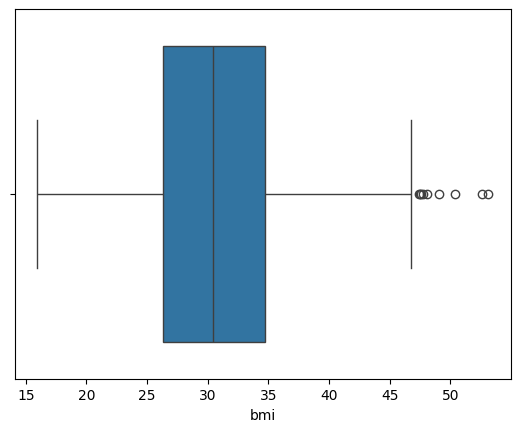

In [76]:
sns.boxplot(x=df["bmi"])

<Axes: xlabel='charges', ylabel='Count'>

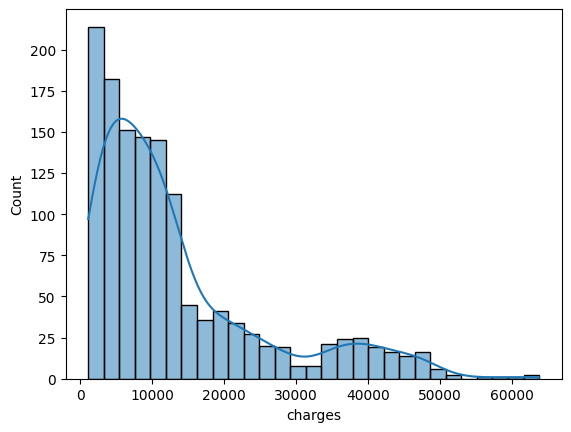

In [77]:
sns.histplot(df["charges"], kde=True)

<Axes: xlabel='charges'>

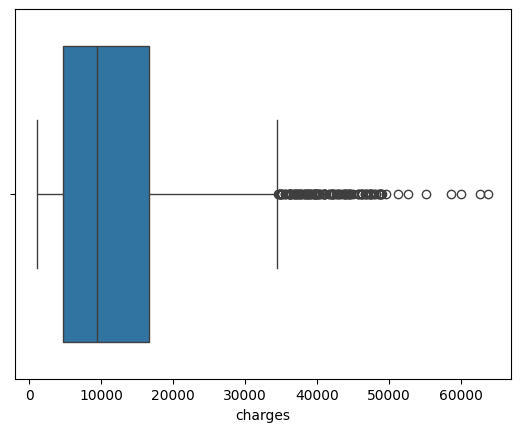

In [78]:
sns.boxplot(x=df["charges"])

<Axes: xlabel='smoker_yes', ylabel='count'>

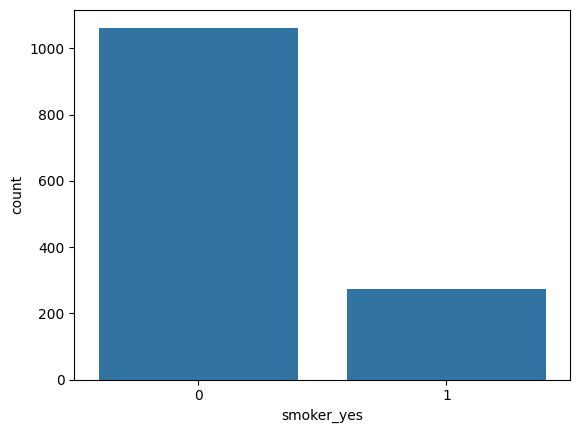

In [ ]:
#1 indicates that is smoker 
#2 indicates that the major of study poulation is non smoker popualtion
sns.countplot(x="smoker_yes", data=df)

<Axes: xlabel='sex_female', ylabel='count'>

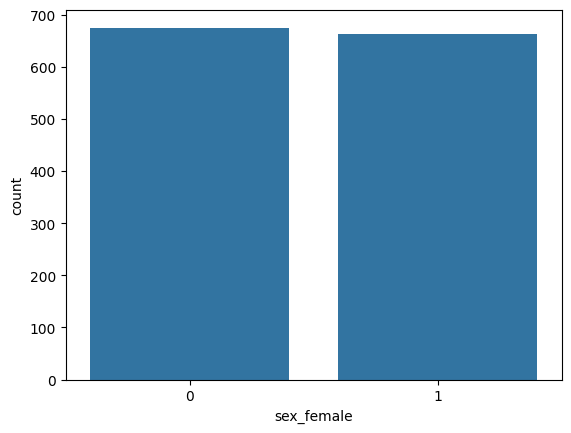

In [80]:
sns.countplot(x="sex_female", data=df)

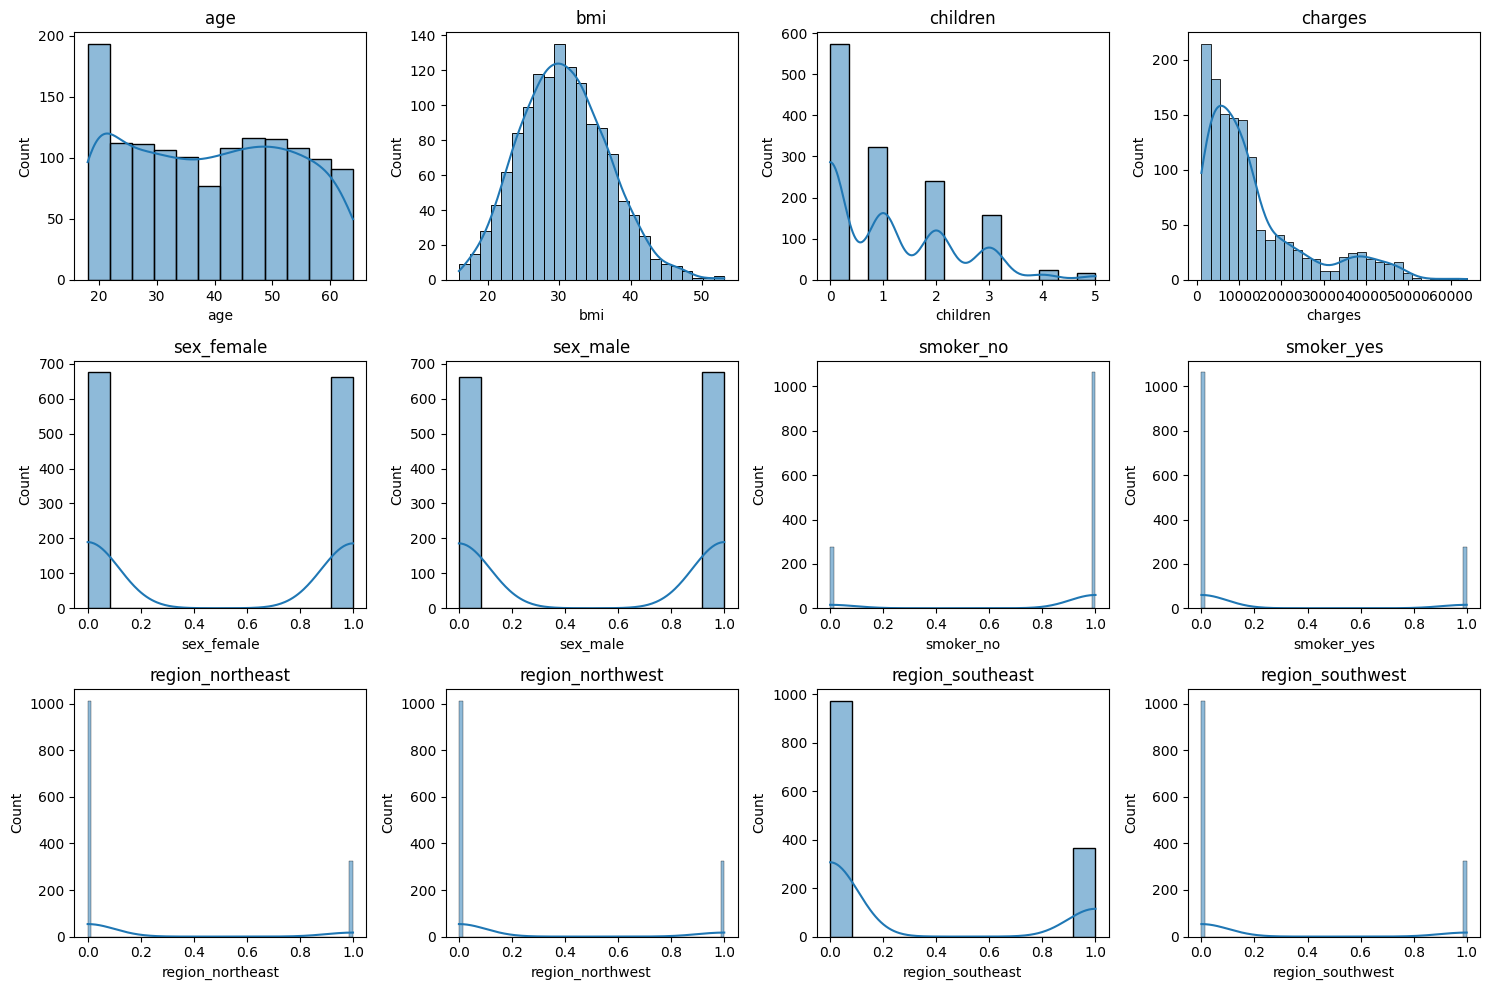

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(15,10)
)

axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

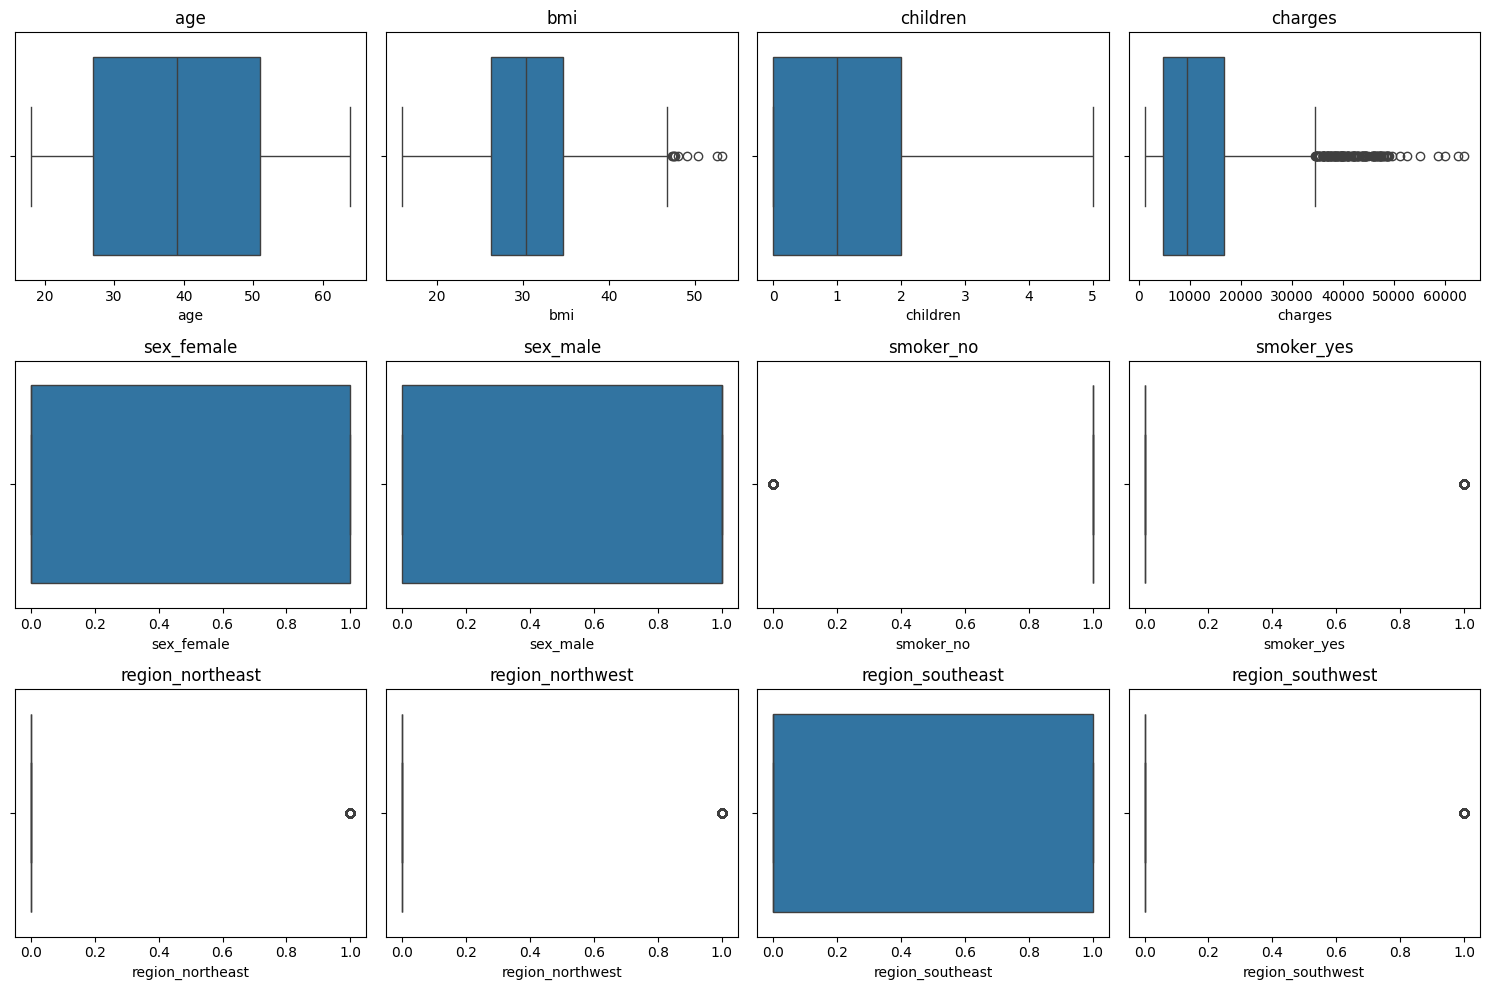

In [82]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(15,10)
)

axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [83]:
outliers_charges = df[df["charges"] > 35000]
outliers_charges["smoker_yes"].value_counts()

smoker_yes
1    130
0      3
Name: count, dtype: int64

In [84]:
## this outlier can indicate that the posibility that most of the charges implier elvted cost in whic are involved smoker population
outliers_charges[
    ["age","bmi","smoker_yes","charges"]
].sort_values(
    "charges",
    ascending=False
).head(20)

,age,bmi,smoker_yes,charges
543,54,47.410,1,63770.42801
1300,45,30.360,1,62592.87309
1230,52,34.485,1,60021.39897
577,31,38.095,1,58571.07448
819,33,35.530,1,55135.40209
1146,60,32.800,1,52590.82939
34,28,36.400,1,51194.55914
1241,64,36.960,1,49577.66240
1062,59,41.140,1,48970.24760
488,44,38.060,1,48885.13561


In [ ]:
"""The variable charges exhibits a strongly right-skewed distribution, with numerous extreme values above USD 35,000. These observations appear to be valid records rather than data-entry errors. The BMI variable also contains several outliers associated with individuals presenting severe obesity. Because these values represent realistic cases within the population, they were retained in the dataset and not removed during preprocessing."""

<Axes: xlabel='smoker_yes', ylabel='charges'>

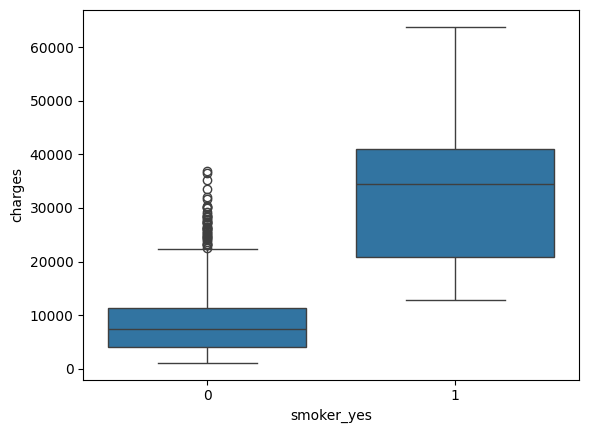

In [85]:
sns.boxplot(
    x="smoker_yes",
    y="charges",
    data=df
)

In [87]:
"""The exploratory analysis reveals a substantial difference between smokers and non-smokers. Smokers display a significantly higher median medical cost and greater variability in expenditures. Furthermore, most of the extremely high medical charges correspond to smokers, suggesting that smoking is one of the strongest factors associated with increased healthcare costs within this population."""

'El análisis exploratorio muestra una diferencia sustancial entre fumadores y no fumadores. Los fumadores presentan una mediana de costos médicos significativamente superior, así como una mayor dispersión en los gastos. Además, la mayoría de los costos extremadamente altos corresponden a pacientes fumadores, lo que sugiere que el tabaquismo es uno de los principales\nfactores asociados con el incremento de los costos médicos en la población \nanalizada.'

### Correlation Analysis and Relationships with Medical Charges

In [88]:
corr_charges = df.corr(numeric_only=True)["charges"] \
                 .sort_values(ascending=False)

print(corr_charges)

charges             1.000000
smoker_yes          0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex_male            0.058044
region_northeast    0.005945
region_northwest   -0.038695
region_southwest   -0.043637
sex_female         -0.058044
smoker_no          -0.787234
Name: charges, dtype: float64


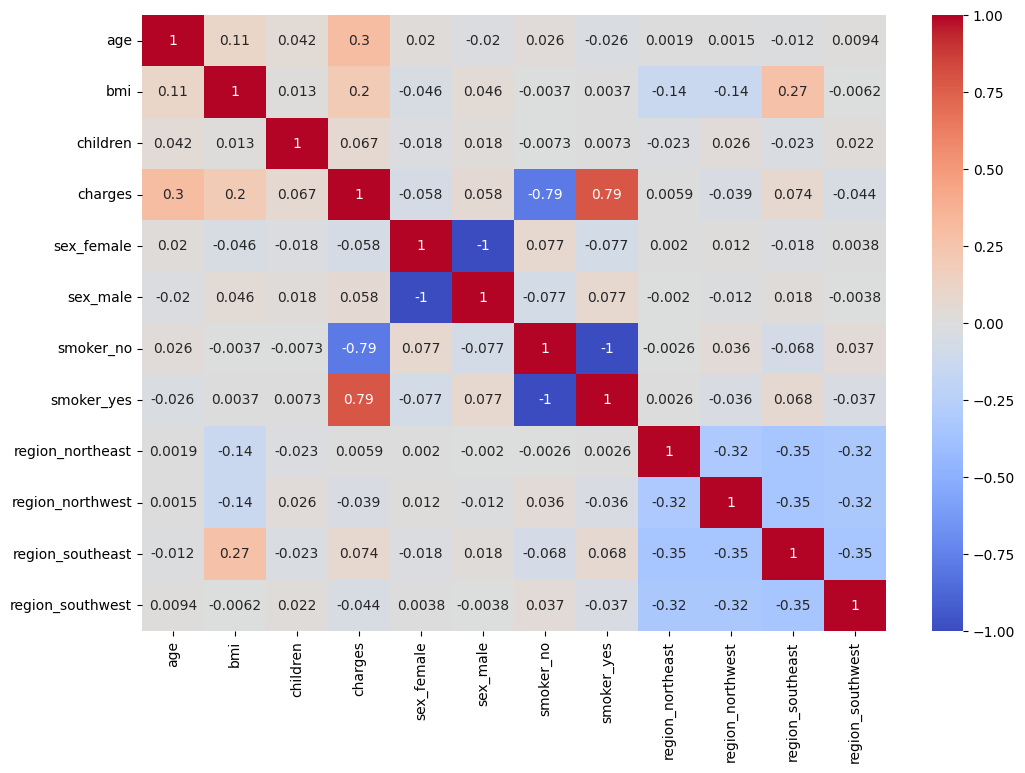

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

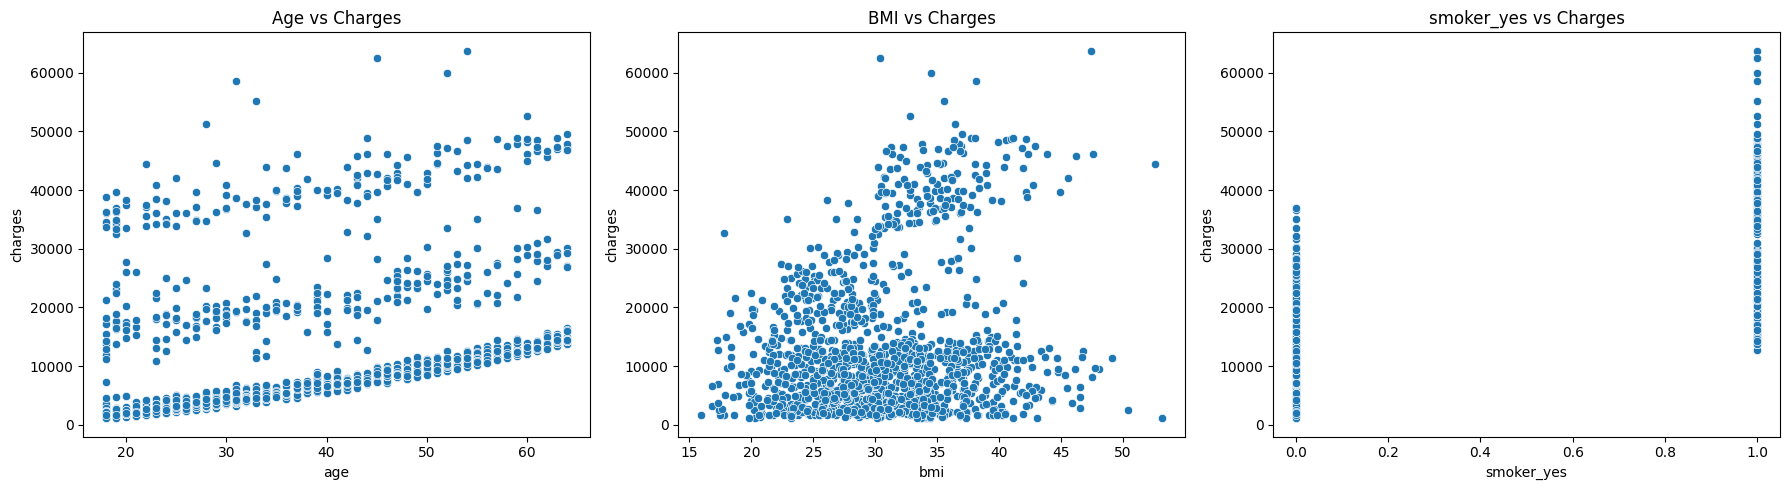

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18,5)
)

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    ax=axes[0]
)
axes[0].set_title("Age vs Charges")

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    ax=axes[1]
)
axes[1].set_title("BMI vs Charges")

sns.scatterplot(
    data=df,
    x="smoker_yes",
    y="charges",
    ax=axes[2]
)
axes[2].set_title("Smoking Status vs Charges")

plt.tight_layout()
plt.show()

<Axes: xlabel='bmi', ylabel='charges'>

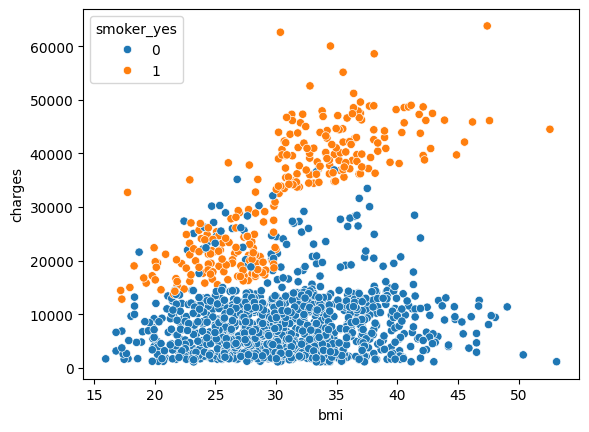

In [93]:
sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker_yes"
)

The joint analysis of BMI and smoking status reveals that smokers incur substantially higher medical costs than non-smokers with comparable BMI values. Moreover, the highest medical expenses observed in the dataset are almost exclusively associated with smokers. These findings suggest that smoking is one of the most influential factors driving medical costs and that its effect may be amplified among individuals with elevated BMI values.

## Smoking Population Composition and Cost Impact by Gender

In [95]:
pd.crosstab(
    df["sex_female"],
    df["smoker_yes"],
    normalize="columns"
) * 100

smoker_yes,0,1
sex_female,,
0,48.541863,58.029197
1,51.458137,41.970803


In [ ]:
"""The smoking population is predominantly composed of men (58.03%), whereas women account for 41.97% of smokers. In contrast, the non-smoking population is more evenly distributed between genders."""

<Axes: xlabel='sex_female', ylabel='charges'>

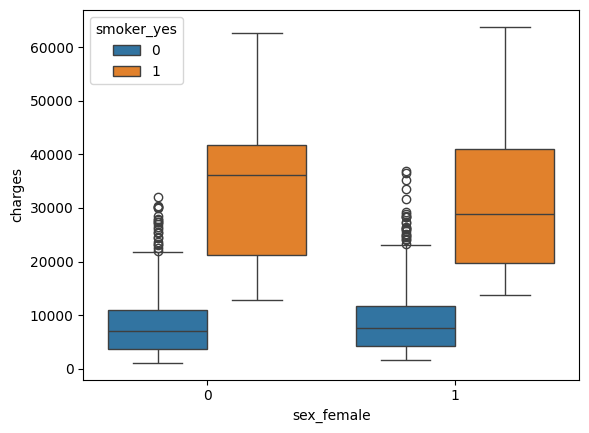

In [96]:
sns.boxplot(
    x="sex_female",
    y="charges",
    hue="smoker_yes",
    data=df
)

### Key Findings by Gender and Smoking Status

Female smokers and male smokers incur substantially higher medical costs than their non-smoking counterparts.

Non-smokers: approximately USD 5,000–10,000

Smokers: approximately USD 20,000–40,000

These results indicate that smoking has a far greater impact on medical costs than gender alone.

In [97]:
df.groupby(
    ["sex_female","smoker_yes"]
)["charges"].mean()

sex_female  smoker_yes
0           0              8099.700161
            1             33042.005975
1           0              8762.297300
            1             30678.996276
Name: charges, dtype: float64

In [98]:
df.groupby(
    ["sex_female","smoker_yes"]
)["charges"].median()

sex_female  smoker_yes
0           0              6986.101975
            1             36085.219000
1           0              7639.417450
            1             28950.469200
Name: charges, dtype: float64

In [ ]:
"""The results indicate that gender has a limited impact on medical expenses. Male and female non-smokers exhibit very similar average medical costs. However, smoking is associated with a substantial increase in healthcare expenditure for both genders, raising average costs by nearly four times compared with non-smokers. This suggests that smoking behaviour is a much stronger determinant of medical costs than gender."""

## Train-Test Split

In [100]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [103]:
print(X.shape)
print(y.shape)

(1337, 11)
(1337,)


In [104]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0
)

In [105]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (935, 11)
X_test: (402, 11)
y_train: (935,)
y_test: (402,)


## Model Evaluation Function

In [106]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results = {
        "R2_train": r2_score(y_train, train_pred),
        "R2_test": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    }

    return results

## Simple Linear Regression

In [107]:
X_simple = df[["smoker_yes"]]
y = df["charges"]

In [109]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.3,
    random_state=0
)

In [110]:
from sklearn.linear_model import LinearRegression
lr_simple = LinearRegression()
lr_simple.fit(X_train_s, y_train_s)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[23220.46]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['smoker_yes']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8394
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [111]:
evaluate_model(lr_simple,X_train_s,X_test_s,y_train_s,y_test_s)

{'R2_train': 0.6231496461001471,
 'R2_test': 0.6113351239111664,
 'MAE': 5978.598016493222,
 'RMSE': np.float64(7977.94375975265)}

## Multiple Linear Regression

In [ ]:
X_selected = df[["age","bmi","smoker_yes"]]
y = df["charges"]

In [114]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected,y,test_size=0.3,
random_state=0)


In [115]:
lr_multiple = LinearRegression()
lr_multiple.fit( X_train_sel,y_train_sel)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 244.7 , 284.07,23659.92]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','bmi','smoker_yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.008e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [116]:
evaluate_model(lr_multiple,X_train_sel,X_test_sel,y_train_sel,y_test_sel)

{'R2_train': 0.7386718262322491,
 'R2_test': 0.7606965669130696,
 'MAE': 4222.571855902198,
 'RMSE': np.float64(6260.0497915707465)}

In [118]:
#This one indacte to us what is the cost of the afe and , be a smoker and age to the medical charges
coef_df = pd.DataFrame({
    "Variable": X_train_sel.columns,
    "Coeficient": lr_multiple.coef_
})

coef_df

,Variable,Coeficient
0,age,244.703015
1,bmi,284.074529
2,smoker_yes,23659.923174


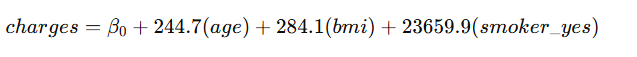

this indicates that each asdditonal age year the medical cost incrment in 245 USD, 
and also that for each additional uniti of BMi the cost incremente in 284 USD,
finally the most representative vlaue in the charge ist is somker_yes, which indicates that is thje patioent is smoker the charges add 23660 USD value

## Decision Tree Regression

In [119]:
from sklearn.tree import DecisionTreeRegressor

In [120]:
X_selected = df[["age","bmi","smoker_yes"]]

In [121]:
tree = DecisionTreeRegressor(random_state=0)
tree.fit(X_train_sel,y_train_sel)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [122]:
evaluate_model(tree,X_train_sel,X_test_sel,y_train_sel,y_test_sel)

{'R2_train': 0.9959221155347041,
 'R2_test': 0.7747601582341113,
 'MAE': 2989.6995698482583,
 'RMSE': np.float64(6073.316717846743)}

In [127]:
results = []

for depth in range(1,11):

    tree = DecisionTreeRegressor(
        max_depth=depth,
        random_state=0
    )

    tree.fit(X_train_sel, y_train_sel)

    metrics = evaluate_model(
        tree,
        X_train_sel,
        X_test_sel,
        y_train_sel,
        y_test_sel
    )

    metrics["Depth"] = depth

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df

,R2_train,R2_test,MAE,RMSE,Depth
0,0.623150,0.611335,5978.598016,7977.943760,1
1,0.828298,0.823346,3575.873948,5378.551392,2
2,0.857677,0.846871,3093.642218,5007.626425,3
3,0.866494,0.846729,2943.654023,5009.953353,4
4,0.876902,0.826721,3029.817359,5326.922229,5
5,0.894807,0.809344,3034.113217,5587.644004,6
6,0.907664,0.813473,2861.318625,5526.811214,7
7,0.922913,0.817589,2789.538850,5465.488857,8
8,0.939542,0.802446,2834.700608,5687.824869,9
9,0.955047,0.793392,2859.537909,5816.703254,10


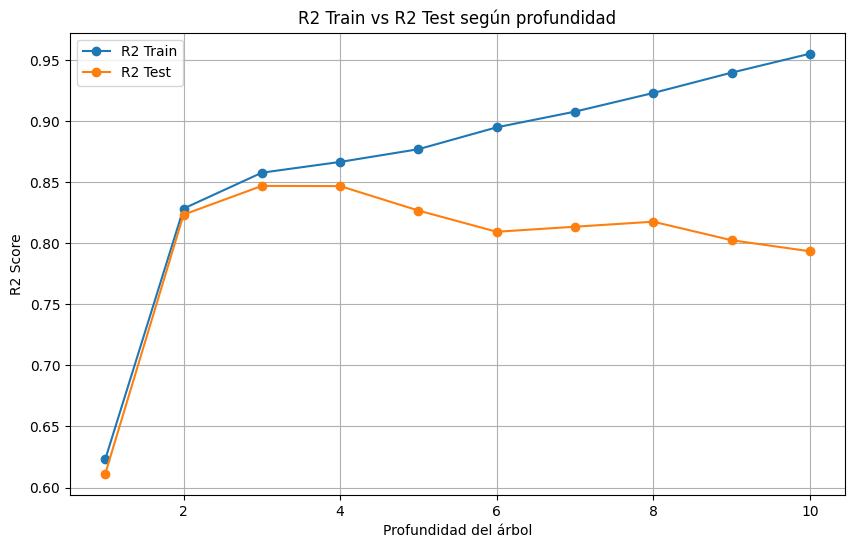

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(results_df["Depth"], results_df["R2_train"], marker="o", label="R² Train")
plt.plot(results_df["Depth"], results_df["R2_test"], marker="o", label="R² Test")

plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("R² Train vs R² Test by Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

## Model Performance Comparison

In [135]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Regression",
        "Multiple Regression",
        "Decision Tree (Depth=3)"
    ],
    "R2_Test": [
        0.611,
        0.761,
        0.847
    ],
    "MAE": [
        5978,
        4223,
        3094
    ],
    "RMSE": [
        7978,
        6260,
        5008
    ]
})


### R² Score Comparison

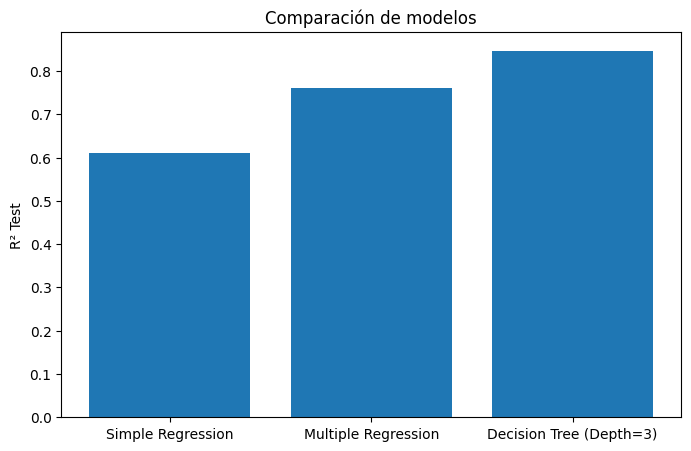

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["R2_Test"]
)

plt.ylabel("R² Test")
plt.title("Model Comparison")
plt.show()

### Mean Absolute Error (MAE) Comparison

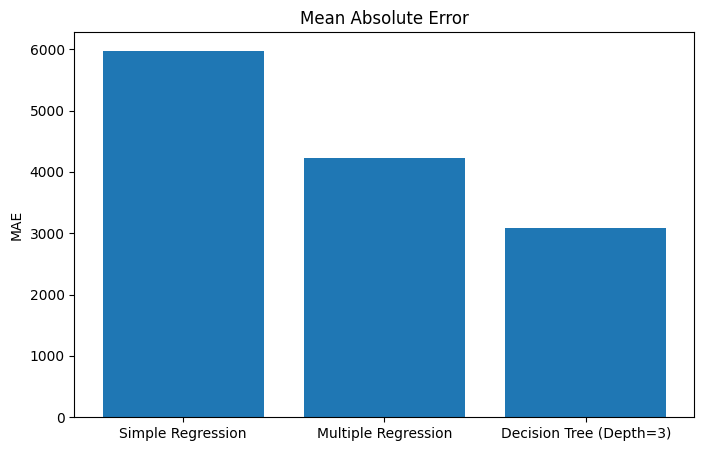

In [137]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.ylabel("MAE")
plt.title("Mean Absolute Error")
plt.show()

### Root Mean Squared Error (RMSE) Comparison

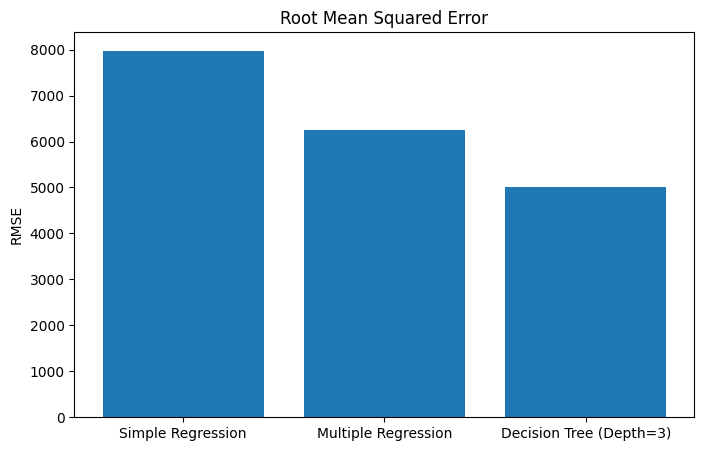

In [138]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Root Mean Squared Error")
plt.show()

## Decision Tree Visualisation and Interpretation

In [139]:
pd.DataFrame({
    "Variable": X_train_sel.columns,
    "Feature Importance": tree.feature_importances_
})

,Variable,Importancia
0,age,0.118736
1,bmi,0.228784
2,smoker_yes,0.652481


In [145]:
from sklearn.tree import DecisionTreeRegressor

best_tree = DecisionTreeRegressor(
    max_depth=3,
    random_state=0
)

best_tree.fit(
    X_train_sel,
    y_train_sel
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_

In [148]:
pd.DataFrame({
    "Variable": X_train_sel.columns,
    "Feature Importance": best_tree.feature_importances_
}).sort_values(
    by="Feature Importance",
    ascending=False
)

,Variable,Importancia
2,smoker_yes,0.726555
1,bmi,0.166923
0,age,0.106522


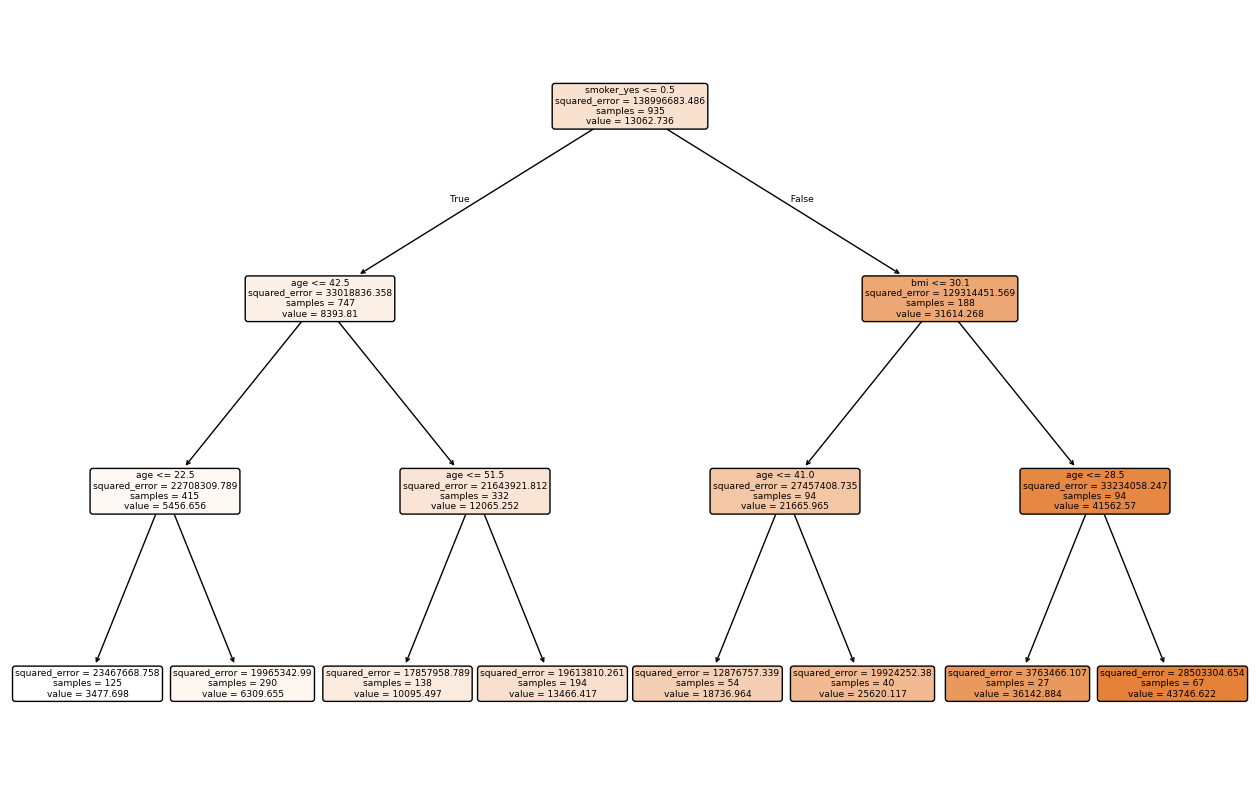

In [146]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))

plot_tree(
    best_tree,
    feature_names=X_train_sel.columns,
    filled=True,
    rounded=True
)

plt.show()

# Executive Summary and Final Recommendations

## Research Objectives

This project aimed to identify the key factors influencing medical insurance charges, quantify the impact of smoking on healthcare expenditures, analyse the composition of the smoking population by gender, and compare the predictive performance of different regression models.

---

## Key Findings

### Research Question 1: Which variables have the greatest influence on medical insurance charges?

The analysis consistently identified smoking status, BMI, and age as the most influential predictors of medical insurance costs.

According to the optimised Decision Tree model:

| Variable | Importance |
|-----------|-----------:|
| Smoking Status | 72.66% |
| BMI | 16.69% |
| Age | 10.65% |

Smoking status emerged as the dominant factor affecting healthcare expenditures, followed by BMI and age.

---

### Research Question 2: What is the impact of smoking on medical costs?

Smoking was associated with a substantial increase in healthcare expenditures. The Multiple Linear Regression model estimated that, holding age and BMI constant, smokers incur approximately USD 23,660 more in medical expenses than non-smokers.

The exploratory analysis also showed a clear separation between smokers and non-smokers, with the highest medical charges concentrated mainly among smokers.

---

### Research Question 3: What proportion of smokers are women and how does smoking affect medical costs by gender?

The smoking population was composed of approximately:

- 58.03% men
- 41.97% women

However, the analysis showed that smoking status has a far greater impact on healthcare costs than gender alone. Male and female non-smokers exhibited similar medical costs, whereas both male and female smokers had substantially higher expenses.

---

## Model Comparison Summary

| Model | R² Test | MAE | RMSE |
|---------|---------:|---------:|---------:|
| Simple Linear Regression | 0.611 | 5,978 | 7,978 |
| Multiple Linear Regression | 0.761 | 4,223 | 6,260 |
| Decision Tree Regression (Depth = 3) | 0.847 | 3,094 | 5,008 |

The Decision Tree Regression model achieved the strongest predictive performance, explaining approximately 84.7% of the variance in medical insurance charges.

---

## Final Conclusions

1. Smoking status is the strongest predictor of medical insurance costs.
2. BMI is the second most influential factor, particularly among smokers.
3. Age contributes positively to healthcare expenditures, although its effect is smaller than smoking and BMI.
4. Gender alone has limited explanatory power.
5. Individuals who smoke and have elevated BMI values represent the highest-cost population segment.
6. A shallow Decision Tree model outperformed the linear models, suggesting that non-linear interactions exist within the data.

---

## Business Recommendations

1. Prioritise smoking prevention and cessation programmes, as smoking represents the largest contributor to healthcare expenditure.
2. Develop targeted interventions for smokers with elevated BMI values, as this group presents the highest expected medical costs.
3. Use predictive analytics to identify high-risk individuals and support preventive healthcare strategies.
4. Consider interpretable non-linear models, such as Decision Trees, for healthcare cost prediction because they provide strong performance and transparent decision rules.
5. Incorporate additional health-related variables in future analyses, such as pre-existing conditions, exercise habits, alcohol consumption, and medical history, to improve predictive accuracy and support better decision-making.
